### Overview

Permutation importance analysis of Rank-SVM on SCAN-B HiSeq training set (80%)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import scipy.stats as stats
from sklearn import metrics
import random
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Import and prepare input data

In [2]:
# import tpm counts training set
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [3]:
# keep only PAM50 genes
X_train = train_data.iloc[:, 0:50]
print(X_train.shape)

(2204, 50)


In [4]:
# import PAM50 file
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [5]:
# check for match
print(X_train.columns.tolist() == pam50['ensembl_gene_id'].tolist())

True


In [6]:
# rename the columns
X_train.columns = pam50['new_gene_symbol']

In [7]:
# save sample subtype info separately as y_train 
y_train = train_data.iloc[:, [50]]
print(y_train.shape)

(2204, 1)


In [8]:
# check if the indices of x and y match
print(X_train.index.equals(y_train.index))

True


In [9]:
# label encoding of Y_train
label_encoder = LabelEncoder()
y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])

# check class count before label encoding
print("Class count before label encoding")
print("Train set\n",train_data['subtype'].value_counts())

# check class count after label encoding
print("\nClass count after label encoding")
print("Train set\n",y_train['subtype'].value_counts())

Class count before label encoding
Train set
 subtype
LumA     1119
LumB      654
Basal     230
Her2      201
Name: count, dtype: int64

Class count after label encoding
Train set
 subtype
2    1119
3     654
0     230
1     201
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_18536\3167366568.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])


In [10]:
# replace gene values by the rank
X_train_ranked = X_train.rank(axis=1, method="min", ascending=False).astype('int')

In [11]:
# scale the ranks between 0 and 1 for each sample
max_rank = len(X_train.columns)
X_train_ranked_scaled = X_train_ranked.apply(lambda row: (row-1) / (max_rank-1), axis=1)

In [12]:
print(X_train_ranked_scaled.shape)

(2204, 50)


In [13]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 2. Rank-SVM Classification

In [14]:
random.seed(seed)
np.random.seed(seed)
    
# build svm classifier
svm = SVC(C=1, gamma=1, kernel='rbf', random_state=seed)

# fit the rfc model on the training fold sets
svm.fit(X_train_ranked_scaled, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_svm = svm.predict(X_train_ranked_scaled)

# calculate metric scores
mcc_svm = metrics.matthews_corrcoef(y_train.values.ravel(), y_pred_svm)
f1_svm = metrics.f1_score(y_train.values.ravel(), y_pred_svm, average='macro')
recall_svm = metrics.recall_score(y_train.values.ravel(), y_pred_svm, average='macro')
precision_svm = metrics.precision_score(y_train.values.ravel(), y_pred_svm, average='macro')
accuracy_svm = metrics.accuracy_score(y_train.values.ravel(), y_pred_svm)

print(metrics.classification_report(y_train.values.ravel(), y_pred_svm, digits=4))


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       230
           1     1.0000    0.9801    0.9899       201
           2     0.9910    0.9848    0.9879      1119
           3     0.9684    0.9847    0.9765       654

    accuracy                         0.9859      2204
   macro avg     0.9899    0.9874    0.9886      2204
weighted avg     0.9861    0.9859    0.9860      2204



In [15]:
print('Accuracy: ', round(accuracy_svm,4))
print('Macro Precision: ', round(precision_svm,4))
print('Macro Recall: ', round(recall_svm,4))
print('Macro F1: ', round(f1_svm,4))
print('Macro MCC: ', round(mcc_svm,4))

Accuracy:  0.9859
Macro Precision:  0.9899
Macro Recall:  0.9874
Macro F1:  0.9886
Macro MCC:  0.9779


#### 3. Spearman Rank Correlation

In [16]:
# Compute pairwise Spearman correlation (better for rank data than Pearson)
train_corr_matrix = pd.DataFrame(X_train_ranked_scaled).corr(method='spearman')

In [17]:
# Find all pairs with high correlation
high_corr_pairs = []
for i in range(len(train_corr_matrix.columns)):
    for j in range(i+1, len(train_corr_matrix.columns)):
        r = train_corr_matrix.iloc[i, j]
        if abs(r) >= 0.7:
            high_corr_pairs.append({
                'gene1': train_corr_matrix.columns[i],
                'gene2': train_corr_matrix.columns[j],
                'spearman_r': round(r, 3)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('spearman_r', 
                                                           ascending=False)

In [18]:
high_corr_df

,gene1,gene2,spearman_r
16,KRT17,KRT5,0.869
14,KRT14,KRT5,0.862
13,KRT14,KRT17,0.835
5,CDC20,KIF2C,0.829
22,MYBL2,UBE2C,0.805
4,BIRC5,UBE2C,0.789
7,CDC20,UBE2C,0.785
18,KRT5,MIA,0.782
23,PTTG1,UBE2C,0.779
15,KRT14,MIA,0.776


#### 4. Permutation Feature Importance 

In [19]:
score_f1 = metrics.make_scorer(metrics.f1_score, average='macro')

In [20]:
svm_permutation = permutation_importance(svm, X_train_ranked_scaled, y_train, n_repeats=50, scoring=score_f1,
                                         random_state=seed)

In [21]:
# organize the importance of features as a df and sort the features by importance score in descending order
svm_feature_importance = pd.DataFrame({'gene': X_train_ranked_scaled.columns, 
                                       'importance_score': svm_permutation.importances_mean, 
                                      'importance_std': svm_permutation.importances_std})
svm_feature_importance = svm_feature_importance.sort_values(ascending=False, by='importance_score').reset_index(drop=True)

# select top 10 
top10 = svm_feature_importance.iloc[0:10]
top10

,gene,importance_score,importance_std
0,ESR1,0.021460,0.003606
1,SFRP1,0.017642,0.002302
2,FGFR4,0.011919,0.001884
3,NAT1,0.011575,0.001838
4,MAPT,0.009861,0.001833
5,MYBL2,0.008418,0.001651
6,TMEM45B,0.008337,0.001507
7,GRB7,0.006951,0.001349
8,PGR,0.006080,0.001240
9,CDH3,0.005540,0.001665


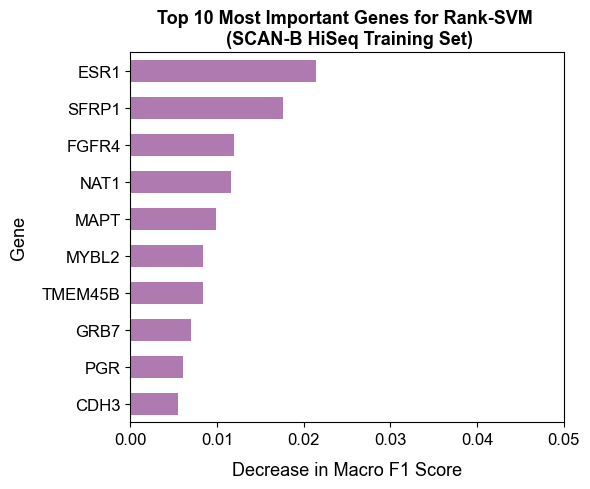

In [32]:
# permutation importance plot
plt.figure(figsize=(6, 5))
sns.barplot(x=top10['importance_score'], y=top10['gene'], color='#b871b9', width=0.6)
plt.title('Top 10 Most Important Genes for Rank-SVM \n (SCAN-B HiSeq Training Set)',
    fontdict={'size': 13, 'color': 'black', 'family': 'Arial', 'weight': 'bold'})
plt.xlabel('Decrease in Macro F1 Score', fontdict={'size': 13, 'color': 'black', 'family': 'Arial'}, labelpad=10)
plt.ylabel('Gene', fontdict={'size': 13, 'color': 'black', 'family': 'Arial'},labelpad=10)
plt.xticks(fontsize=12, color='black', fontfamily='Arial')
plt.yticks(fontsize=12, color='black', fontfamily='Arial')
plt.xlim(0, 0.05)
plt.tight_layout()
plt.savefig('scanb_hiseq_train_rank_svm_permutation.png', dpi=300, bbox_inches='tight')
plt.show()